In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
import json
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
 
from xcube.core.store import new_data_store
from xcube.core.chunk import chunk_dataset
from xcube.core.gridmapping import GridMapping
from xcube.core.geom import mask_dataset_by_geometry
from xcube_resampling.spatial import resample_in_space
from xcube_resampling.gridmapping import GridMapping

## Konstantin

Please adjust the cluster as needed

In [2]:
from dask.distributed import Client, LocalCluster
import dask

cluster = LocalCluster(
    n_workers=4,              
    threads_per_worker=2,
    memory_limit='6GB', # per worker
)
client = Client(cluster)
client

/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40085 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:40085/status,
Dashboard: http://127.0.0.1:40085/status,Workers: 4
Total threads: 8,Total memory: 22.35 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42419,Workers: 0
Dashboard: http://127.0.0.1:40085/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37495,Total threads: 2
Dashboard: http://127.0.0.1:36087/status,Memory: 5.59 GiB
Nanny: tcp://127.0.0.1:33065,


In [3]:
bbox = [-11, 35, 50, 72] # Europe

In [4]:
import os
S3_USER_STORAGE_KEY = os.environ["S3_USER_STORAGE_KEY"]
S3_USER_STORAGE_SECRET = os.environ["S3_USER_STORAGE_SECRET"]
S3_USER_STORAGE_BUCKET = os.environ["S3_USER_STORAGE_BUCKET"]

In [5]:
irr_store = new_data_store("s3",
                       root=S3_USER_STORAGE_BUCKET,
                       storage_options=dict(anon=False,
                                            key=S3_USER_STORAGE_KEY,
                                            secret=S3_USER_STORAGE_SECRET))

In [6]:
irr_store.list_data_ids()

['deleteme.zarr',
 'era5.zarr',
 'era5v2.zarr',
 'era5v3.zarr',
 'era5v3_timeopt.zarr',
 'irrigation_input.zarr',
 'soil_moisture_filled.zarr',
 'soil_moisture_zappend.zarr']

In [7]:
soil_moisture = irr_store.open_data("soil_moisture_zappend.zarr")
soil_moisture

<xarray.Dataset> Size: 403GB
Dimensions:  (time: 3561, lat: 4144, lon: 6832)
Coordinates:
  * time     (time) datetime64[ns] 28kB 2016-01-01 2016-01-02 ... 2025-09-30
  * lat      (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon      (lon) float64 55kB -11.0 -10.99 -10.98 -10.97 ... 49.98 49.99 50.0
Data variables:
    SWI      (time, lat, lon) float32 403GB dask.array<chunksize=(3561, 150, 150), meta=np.ndarray>

In [8]:
cds_cube_daily = irr_store.open_data("era5v3_timeopt.zarr")
cds_cube_daily

<xarray.Dataset> Size: 6GB
Dimensions:  (time: 3561, lat: 373, lon: 611)
Coordinates:
  * time     (time) datetime64[ns] 28kB 2016-01-01T23:00:00 ... 2025-09-30T23...
  * lat      (lat) float64 3kB 72.0 71.9 71.8 71.7 71.6 ... 35.1 35.0 34.9 34.8
  * lon      (lon) float64 5kB -11.0 -10.9 -10.8 -10.7 ... 49.7 49.8 49.9 50.0
Data variables:
    pev      (time, lat, lon) float32 3GB dask.array<chunksize=(3561, 50, 50), meta=np.ndarray>
    tp       (time, lat, lon) float32 3GB dask.array<chunksize=(3561, 50, 50), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-10-17T13:43 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [9]:
store_lccs=new_data_store("s3", root="deep-esdl-public", storage_options=dict(anon=True))

In [10]:
mlds_lc = store_lccs.open_data("LC-1x2025x2025-2.0.0.levels")
lc = mlds_lc.base_dataset
lc = lc.sel(time="2020-01-01")
lc = lc[["crs", "lccs_class"]]
lc

<xarray.Dataset> Size: 8GB
Dimensions:     (lat: 64800, lon: 129600)
Coordinates:
  * lat         (lat) float64 518kB 90.0 90.0 89.99 89.99 ... -89.99 -90.0 -90.0
  * lon         (lon) float64 1MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    time        datetime64[ns] 8B 2020-01-01
Data variables:
    crs         int32 4B ...
    lccs_class  (lat, lon) uint8 8GB dask.array<chunksize=(2025, 2025), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.6
    TileSize:                   2025:2025
    cdm_data_type:              grid
    comment:                    
    contact:                    https://www.ecmwf.int/en/about/contact-us/get...
    creation_date:              20181130T095451Z
    ...                         ...
    time_coverage_end:          19921231
    time_coverage_resolution:   P1Y
    time_coverage_start:        19920101
    title:                      Land Cover Map of ESA CCI brokered by CDS
    tracking_id:                61b96fd7-42c3-4374-9de1-0dc3b0bcae2a
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y

### Soil Moisture (CLMS) - Interpolation

## LandCover - Subset and Binarization

In [7]:
full_time = pd.date_range(start=clms_data.time.min().item(),
                          end=clms_data.time.max().item(),
                          freq="D")

clms_data = clms_data.reindex(time=full_time)
clms_data

/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/dask/array/core.py:4997: PerformanceWarning: Increasing number of chunks by factor of 28
  result = blockwise(


<xarray.Dataset> Size: 403GB
Dimensions:  (lat: 4144, lon: 6832, time: 3561)
Coordinates:
  * lat      (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon      (lon) float64 55kB -11.0 -10.99 -10.98 -10.97 ... 49.98 49.99 50.0
  * time     (time) datetime64[ns] 28kB 2016-01-01 2016-01-02 ... 2025-09-30
Data variables:
    crs      (time) object 28kB dask.array<chunksize=(29,), meta=np.ndarray>
    ssm      (time, lat, lon) float32 403GB dask.array<chunksize=(3561, 150, 150), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2019
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2016-01-01T23:59:59Z
    time_coverage_start:       2016-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2016-01...

In [8]:
def swicomp_nan(in_data, in_jd, ctime=2):
    filtered = np.empty(len(in_data))
    gain = 1
    filtered.fill(np.nan)

    ID = np.where(~np.isnan(in_data))
    if len(ID[0]) == 0:
        return filtered

    D = in_jd[ID]
    SWI = in_data[ID].copy()
    tdiff = np.diff(D)

    for i in range(2, SWI.size):
        gain = gain / (gain + np.exp(- tdiff[i - 1] / ctime))
        SWI[i] = SWI[i - 1] + gain * (SWI[i] - SWI[i-1])

    filtered[ID] = SWI
    return filtered

In [9]:
julian_dates = xr.DataArray(
    pd.to_datetime(clms_data.time.values).to_julian_date().values,
    dims='time',
    coords={'time': clms_data.time}
)
julian_dates

<xarray.DataArray (time: 3561)> Size: 28kB
array([2457388.5, 2457389.5, 2457390.5, ..., 2460946.5, 2460947.5,
       2460948.5], shape=(3561,))
Coordinates:
  * time     (time) datetime64[ns] 28kB 2016-01-01 2016-01-02 ... 2025-09-30

In [10]:
sm_filled = clms_data['ssm'].interpolate_na(dim='time', method='linear')

sm_clipped = sm_filled.clip(max=100)

sm_normalized = ((sm_clipped - sm_clipped.min(dim="time")) / (sm_clipped.max(dim="time") - sm_clipped.min(dim="time")))

sm_normalized

<xarray.DataArray 'ssm' (time: 3561, lat: 4144, lon: 6832)> Size: 403GB
dask.array<truediv, shape=(3561, 4144, 6832), dtype=float32, chunksize=(3561, 150, 150), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 28kB 2016-01-01 2016-01-02 ... 2025-09-30
  * lat      (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon      (lon) float64 55kB -11.0 -10.99 -10.98 -10.97 ... 49.98 49.99 50.0

In [11]:
SWI = xr.apply_ufunc(
    swicomp_nan,
    sm_normalized,
    julian_dates,
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized",
    kwargs={"ctime": 2},
    output_dtypes=[clms_data.ssm.dtype]
)

In [12]:
SWI = SWI.transpose("time", "lat", "lon")
SWI

<xarray.DataArray (time: 3561, lat: 4144, lon: 6832)> Size: 403GB
dask.array<transpose, shape=(3561, 4144, 6832), dtype=float32, chunksize=(3561, 150, 150), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 28kB 2016-01-01 2016-01-02 ... 2025-09-30
  * lat      (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon      (lon) float64 55kB -11.0 -10.99 -10.98 -10.97 ... 49.98 49.99 50.0

In [14]:
swi_ds = SWI.to_dataset(name="SWI")

In [20]:
irr_store.write_data(swi_ds, "soil_moisture_filled.zarr", replace=True)

/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home

'soil_moisture_filled.zarr'

In [21]:
soil_moisture = irr_store.open_data("soil_moisture_filled.zarr")
soil_moisture

<xarray.Dataset> Size: 403GB
Dimensions:  (time: 3561, lat: 4144, lon: 6832)
Coordinates:
  * time     (time) datetime64[ns] 28kB 2016-01-01 2016-01-02 ... 2025-09-30
  * lat      (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon      (lon) float64 55kB -11.0 -10.99 -10.98 -10.97 ... 49.98 49.99 50.0
Data variables:
    SWI      (time, lat, lon) float32 403GB dask.array<chunksize=(3561, 150, 150), meta=np.ndarray>

In [11]:
lc_subset = lc.sel(lat=slice(bbox[3], bbox[1]), lon=slice(bbox[0], bbox[2]))
lc_subset

<xarray.Dataset> Size: 293MB
Dimensions:     (lat: 13320, lon: 21960)
Coordinates:
  * lat         (lat) float64 107kB 72.0 72.0 71.99 71.99 ... 35.01 35.0 35.0
  * lon         (lon) float64 176kB -11.0 -11.0 -10.99 ... 49.99 50.0 50.0
    time        datetime64[ns] 8B 2020-01-01
Data variables:
    crs         int32 4B ...
    lccs_class  (lat, lon) uint8 293MB dask.array<chunksize=(1620, 1935), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.6
    TileSize:                   2025:2025
    cdm_data_type:              grid
    comment:                    
    contact:                    https://www.ecmwf.int/en/about/contact-us/get...
    creation_date:              20181130T095451Z
    ...                         ...
    time_coverage_end:          19921231
    time_coverage_resolution:   P1Y
    time_coverage_start:        19920101
    title:                      Land Cover Map of ESA CCI brokered by CDS
    tracking_id:                61b96fd7-42c3-4374-9de1-0dc3b0bcae2a
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y

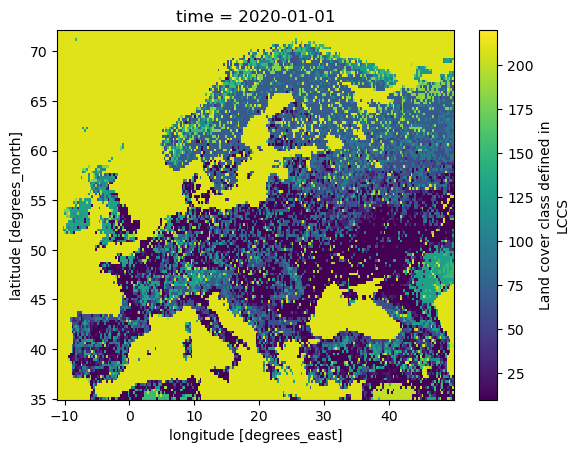

In [12]:
lc_subset.lccs_class.isel(lat=slice(None, None, 100), lon=slice(None, None, 100)).plot()

In [13]:
keep_classes = [10, 11, 12, 20, 30] # These are classes in LandCover related to Croplands

filtered_lc = lc_subset.lccs_class.where(lc_subset["lccs_class"].isin(keep_classes))

keep_classes_np = np.array(keep_classes, dtype=filtered_lc.dtype)

lc_binary = filtered_lc.isin(keep_classes_np).astype("uint8")

lc_binary

<xarray.DataArray 'lccs_class' (lat: 13320, lon: 21960)> Size: 293MB
dask.array<astype, shape=(13320, 21960), dtype=uint8, chunksize=(2025, 2025), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 107kB 72.0 72.0 71.99 71.99 ... 35.01 35.01 35.0 35.0
  * lon      (lon) float64 176kB -11.0 -11.0 -10.99 -10.99 ... 49.99 50.0 50.0
    time     datetime64[ns] 8B 2020-01-01

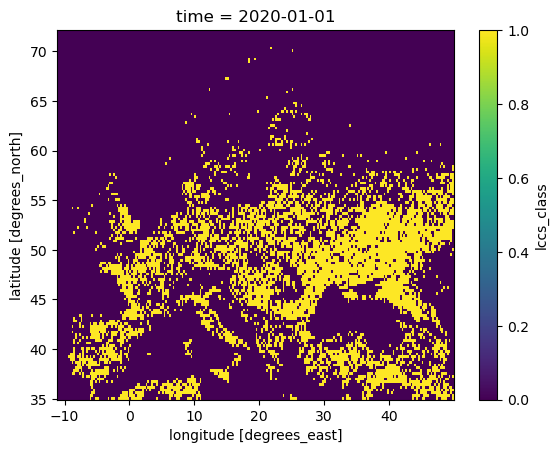

In [14]:
lc_binary.isel(lat=slice(None, None, 100), lon=slice(None, None, 100)).plot()

## CDS - Units modification

In [15]:
cds_cube_daily["pev"] = cds_cube_daily["pev"] * -1  # Flip the signs

In [ ]:
pev_daily  = cds_cube_daily["pev"].resample(time="1D").last() # taking the last as every hour it is cumsum
tp_daily   = cds_cube_daily["tp"].resample(time="1D").last() # taking the last as every hour it is cumsum

cds_cube_daily = xr.merge([pev_daily, tp_daily])

In [16]:
def convert_m_to_mm(dataarray, update_long_name=True):
    converted = dataarray * 1000

    converted.attrs = dataarray.attrs.copy()

    converted.attrs['units'] = 'mm'
    converted.attrs['GRIB_units'] = 'mm'
 
    if update_long_name:
        if 'long_name' in converted.attrs:
            converted.attrs['long_name'] = converted.attrs['long_name'] + ' (millimeters)'
        else:
            converted.attrs['long_name'] = 'Potential evaporation (millimeters)'

    return converted

In [17]:
cds_cube_daily["pev"] =  convert_m_to_mm(cds_cube_daily["pev"])
cds_cube_daily["tp"] =  convert_m_to_mm(cds_cube_daily["tp"])
cds_cube_daily

<xarray.Dataset> Size: 6GB
Dimensions:  (time: 3561, lat: 373, lon: 611)
Coordinates:
  * time     (time) datetime64[ns] 28kB 2016-01-01T23:00:00 ... 2025-09-30T23...
  * lat      (lat) float64 3kB 72.0 71.9 71.8 71.7 71.6 ... 35.1 35.0 34.9 34.8
  * lon      (lon) float64 5kB -11.0 -10.9 -10.8 -10.7 ... 49.7 49.8 49.9 50.0
Data variables:
    pev      (time, lat, lon) float32 3GB dask.array<chunksize=(3561, 50, 50), meta=np.ndarray>
    tp       (time, lat, lon) float32 3GB dask.array<chunksize=(3561, 50, 50), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-10-17T13:43 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Resample ERA5 (CDS) and LC to Soil Moisture (CLMS) grid

In [18]:
gm_sm = GridMapping.from_dataset(soil_moisture)

gm_cds = GridMapping.from_dataset(cds_cube_daily)

gm_lc = GridMapping.from_dataset(lc_binary.to_dataset(name="lc_binary"))

In [19]:
gm_sm

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-11, 35, 50, 72)
* ij_bbox: (0, 0, 6832, 4144)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (6832, 4144)
* tile_size: (150, 150)

In [20]:
gm_cds

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.1, 0.1)
* xy_bbox: (-11.05, 34.75, 50.05, 72.05)
* ij_bbox: (0, 0, 611, 373)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (611, 373)
* tile_size: (50, 50)

In [21]:
gm_lc

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.002777775, 0.002777775)
* xy_bbox: (-11, 35, 50, 72)
* ij_bbox: (0, 0, 21960, 13320)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (21960, 13320)
* tile_size: (2025, 2025)

In [22]:
cds_in_gm_sm = resample_in_space(cds_cube_daily, target_gm = gm_sm)
cds_in_gm_sm = cds_in_gm_sm.assign_coords(time=cds_cube_daily.time) # this step is needed until resample_in_space is fixed
cds_in_gm_sm

<xarray.Dataset> Size: 807GB
Dimensions:      (time: 3561, lat: 4144, lon: 6832)
Coordinates:
  * time         (time) datetime64[ns] 28kB 2016-01-01T23:00:00 ... 2025-09-3...
  * lat          (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon          (lon) float64 55kB -11.0 -10.99 -10.98 ... 49.98 49.99 50.0
    spatial_ref  int64 8B 0
Data variables:
    pev          (time, lat, lon) float32 403GB dask.array<chunksize=(3561, 150, 150), meta=np.ndarray>
    tp           (time, lat, lon) float32 403GB dask.array<chunksize=(3561, 150, 150), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-10-17T13:43 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [23]:
lc_binary.attrs['flag_values'] = [0, 1]
lc_binary.attrs['flag_meanings'] = "no_data croplands_land_cover"
lc_in_gm_sm = resample_in_space(lc_binary.to_dataset(name="lc_binary"), target_gm = gm_sm, agg_methods="mode")
lc_in_gm_sm=lc_in_gm_sm.drop_vars('time')
lc_in_gm_sm

<xarray.Dataset> Size: 28MB
Dimensions:      (lat: 4144, lon: 6832)
Coordinates:
  * lat          (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon          (lon) float64 55kB -11.0 -10.99 -10.98 ... 49.98 49.99 50.0
    spatial_ref  int64 8B 0
Data variables:
    lc_binary    (lat, lon) uint8 28MB dask.array<chunksize=(150, 150), meta=np.ndarray>

## Filtering for landcover classes

In [24]:
cds_masked = cds_in_gm_sm.where(lc_in_gm_sm.lc_binary == 1)
cds_masked

<xarray.Dataset> Size: 807GB
Dimensions:      (time: 3561, lat: 4144, lon: 6832)
Coordinates:
  * time         (time) datetime64[ns] 28kB 2016-01-01T23:00:00 ... 2025-09-3...
  * lat          (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon          (lon) float64 55kB -11.0 -10.99 -10.98 ... 49.98 49.99 50.0
    spatial_ref  int64 8B 0
Data variables:
    pev          (time, lat, lon) float32 403GB dask.array<chunksize=(3561, 150, 150), meta=np.ndarray>
    tp           (time, lat, lon) float32 403GB dask.array<chunksize=(3561, 150, 150), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-10-17T13:43 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [25]:
soil_moisture_masked = soil_moisture.where(lc_in_gm_sm.lc_binary == 1)
soil_moisture_masked

<xarray.Dataset> Size: 403GB
Dimensions:      (time: 3561, lat: 4144, lon: 6832)
Coordinates:
  * time         (time) datetime64[ns] 28kB 2016-01-01 2016-01-02 ... 2025-09-30
  * lat          (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon          (lon) float64 55kB -11.0 -10.99 -10.98 ... 49.98 49.99 50.0
    spatial_ref  int64 8B 0
Data variables:
    SWI          (time, lat, lon) float32 403GB dask.array<chunksize=(3561, 150, 150), meta=np.ndarray>

In [26]:
# soil_moisture_masked = chunk_dataset(soil_moisture_masked, chunk_sizes={"time":-1}, format_name="zarr")
# cds_masked = chunk_dataset(cds_masked, chunk_sizes={"time":-1}, format_name="zarr")

## Merge and Save

In [30]:
cds_masked_aligned = cds_masked.assign_coords(time=soil_moisture_masked.time)
ds_combined = xr.merge([soil_moisture_masked, cds_masked_aligned], join='exact') 
ds_combined

<xarray.Dataset> Size: 1TB
Dimensions:      (time: 3561, lat: 4144, lon: 6832)
Coordinates:
  * time         (time) datetime64[ns] 28kB 2016-01-01 2016-01-02 ... 2025-09-30
  * lat          (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon          (lon) float64 55kB -11.0 -10.99 -10.98 ... 49.98 49.99 50.0
    spatial_ref  int64 8B 0
Data variables:
    SWI          (time, lat, lon) float32 403GB dask.array<chunksize=(3561, 150, 150), meta=np.ndarray>
    pev          (time, lat, lon) float32 403GB dask.array<chunksize=(3561, 150, 150), meta=np.ndarray>
    tp           (time, lat, lon) float32 403GB dask.array<chunksize=(3561, 150, 150), meta=np.ndarray>

> Note
> I added the rechunking here before writing, but never tested. I did the rechunking separately. This may cause problems if it is rerun.  

In [31]:
%%time
ds = chunk_dataset(ds, {"time": -1, "lat": 50, "lon": 50}, format_name="zarr")
irr_store.write_data(ds_combined, "irrigation_input_small_chunks.zarr")

CPU times: user 6min 50s, sys: 45.9 s, total: 7min 36s
Wall time: 1h 5min 2s


'irrigation_input.zarr'

## Quick Test data

In [34]:
irrigation_input = irr_store.open_data("irrigation_input_small_chunks.zarr")
irrigation_input

<xarray.Dataset> Size: 1TB
Dimensions:      (time: 3561, lat: 4144, lon: 6832)
Coordinates:
  * time         (time) datetime64[ns] 28kB 2016-01-01 2016-01-02 ... 2025-09-30
  * lat          (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon          (lon) float64 55kB -11.0 -10.99 -10.98 ... 49.98 49.99 50.0
    spatial_ref  int64 8B ...
Data variables:
    SWI          (time, lat, lon) float32 403GB dask.array<chunksize=(3561, 150, 150), meta=np.ndarray>
    pev          (time, lat, lon) float32 403GB dask.array<chunksize=(3561, 150, 150), meta=np.ndarray>
    tp           (time, lat, lon) float32 403GB dask.array<chunksize=(3561, 150, 150), meta=np.ndarray>

In [35]:
bbox = [-5, 40, 3, 44] # Ebro Basin

In [37]:
ebro_basin = irrigation_input.sel(lat=slice(bbox[3], bbox[1]), lon=slice(bbox[0], bbox[2]))
ebro_basin

<xarray.Dataset> Size: 17GB
Dimensions:      (time: 3561, lat: 448, lon: 896)
Coordinates:
  * time         (time) datetime64[ns] 28kB 2016-01-01 2016-01-02 ... 2025-09-30
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B ...
Data variables:
    SWI          (time, lat, lon) float32 6GB dask.array<chunksize=(3561, 14, 78), meta=np.ndarray>
    pev          (time, lat, lon) float32 6GB dask.array<chunksize=(3561, 14, 78), meta=np.ndarray>
    tp           (time, lat, lon) float32 6GB dask.array<chunksize=(3561, 14, 78), meta=np.ndarray>

/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws

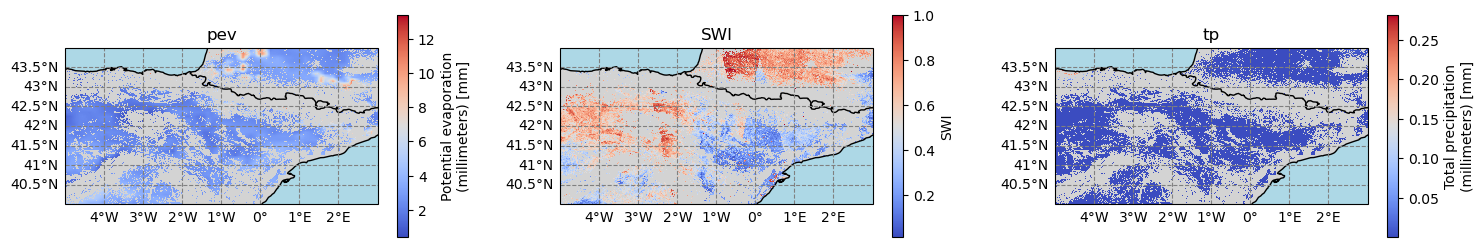

CPU times: user 7.55 s, sys: 973 ms, total: 8.53 s
Wall time: 38.4 s


In [38]:
%%time

ds = ebro_basin.isel(time=50)
vars_to_plot = ["pev", "SWI", "tp"]

proj = ccrs.PlateCarree()
n_vars = len(vars_to_plot)
n_cols = 3
n_rows = -(-n_vars // n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 4*n_rows),
    subplot_kw={"projection": proj}
)

for ax, var in zip(axes.flat, vars_to_plot):
    da = ds[var]
    da.plot(ax=ax, transform=proj, cmap="coolwarm", cbar_kwargs={"shrink": 0.6})
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.set_title(var)
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
    gl.top_labels = False
    gl.right_labels = False


plt.tight_layout()
plt.show()

In [39]:
client.shutdown()